In [1]:
# === Config (edit here) ===
ROOT = "/data1/tpz/nwm-main/results/nwm_cdit_airvln_16/airvln_16/CEM_N6_K5_RS1_rep3_OPT3/editor/run_006"            # 根目录：包含多个子目录，每个子目录有 metadata.json 与 frames/*.png
MASTER_OUT = ROOT + "/master.mp4"  # 输出视频文件名
FPS = 2                    # 合成视频帧率
PAUSE_SEC = 2.0   

In [2]:
# === Imports ===
import os, json
import numpy as np
from pathlib import Path
from PIL import Image, ImageDraw

import matplotlib.pyplot as plt
from matplotlib import gridspec, animation
from IPython.display import HTML

In [3]:
def build_master_animation(root: str, fps: int = 2, pause_sec: float = 0.0, overlay_text: bool = True):
    """
    Build a master animation from runs under `root`.

    Layout:
      - Left  : Current View (frame image, optional step/action overlay)
      - Middle: 3D trajectories (black = finished runs, red = current run) + heading arrow
      - Right : Fixed GT image (ROOT/frames/goal.png), resized to match frames

    Rules:
      - During a run, the red polyline grows with frames.
      - ONLY on that run's *last frame* do we finalize it into a black line.
      - Pause between runs is implemented by repeating the last frame (no on-screen text).

    Returns:
      (fig, anim)  # Matplotlib Figure and FuncAnimation
    """
    root = Path(root)
    run_dirs = sorted({p.parent for p in root.rglob("metadata.json")})
    assert run_dirs, f"No metadata.json found under {root}"

    # --- Fixed global GT at ROOT/frames/goal.png ---
    global_gt_path = root / "frames" / "goal.png"
    assert global_gt_path.exists(), f"Global GT not found: {global_gt_path}"
    global_gt_img = Image.open(global_gt_path).convert("RGB")

    # --- Load all runs: [(frames_rgb, poses, targets_rgb)] ---
    runs = []
    for rd in run_dirs:
        meta = json.load(open(rd / "metadata.json", "r", encoding="utf-8"))
        frames_rgb, poses, targets_rgb = [], [], []

        for f in meta["frames"]:
            # Frame path: allow "frames/xxx.png" or just "xxx.png"
            rel = f["png"]
            p1 = rd / rel
            p2 = rd / Path(rel).name
            png = p1 if p1.exists() else p2
            assert png.exists(), f"Frame not found: {png}"

            img = Image.open(png).convert("RGB")
            if overlay_text:
                step = f.get("frame", 0); act = f.get("action", "")
                draw = ImageDraw.Draw(img)
                draw.text((10, 10), f"Step {step}: {act}", fill=(255, 0, 0))
            frames_rgb.append(np.array(img))

            p = f["pose"]
            poses.append((p["x"], p["y"], p["z"], p["theta_rad"]))
            targets_rgb.append(None)  # placeholder (size set below)

        # Unify size within this run (use first frame as reference)
        h, w = frames_rgb[0].shape[:2]
        for i in range(len(frames_rgb)):
            if frames_rgb[i].shape[:2] != (h, w):
                frames_rgb[i] = np.array(Image.fromarray(frames_rgb[i]).resize((w, h)))

        # Fixed GT for all frames in this run
        gt_resized = np.array(global_gt_img.resize((w, h)))
        targets_rgb = [gt_resized for _ in targets_rgb]

        runs.append((frames_rgb, poses, targets_rgb))

    # --- Global 3D axis limits ---
    all_xyz = np.array([p[:3] for _, poses, _ in runs for p in poses], dtype=np.float32)
    minv = all_xyz.min(axis=0); maxv = all_xyz.max(axis=0)
    pad = 0.05 * max(maxv - minv) or 1.0

    # --- Build schedule with optional silent pauses ---
    # Each item: (run_idx, frame_idx, is_pause, pause_tick)
    pause_frames = int(round(max(0.0, pause_sec) * max(1, fps)))
    schedule = []
    for i, (frames_rgb, _, _) in enumerate(runs):
        T = len(frames_rgb)
        for fidx in range(T):
            schedule.append((i, fidx, False, 0))          # normal frames
        schedule.append((i, T - 1, False, 0))             # one freeze frame
        for k in range(1, pause_frames + 1):
            schedule.append((i, T - 1, True, k))          # extra pauses

    # --- Figure: [Left | Middle(3D) | Right(GT)] ---
    fig = plt.figure(figsize=(15, 6))
    gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1.5, 1])

    ax_img = fig.add_subplot(gs[0]); ax_img.axis('off'); ax_img.set_title("Current View")
    im = ax_img.imshow(runs[0][0][0])

    ax3d = fig.add_subplot(gs[1], projection='3d')
    ax3d.set_title("Overlaid Trajectories (black=done, red=current)")
    ax3d.set_xlim(minv[0] - pad, maxv[0] + pad)
    ax3d.set_ylim(minv[1] - pad, maxv[1] + pad)
    ax3d.set_zlim(minv[2] - pad, maxv[2] + pad)

    ax_gt = fig.add_subplot(gs[2]); ax_gt.axis('off'); ax_gt.set_title("Target (GT for loss)")
    im_gt = ax_gt.imshow(runs[0][2][0])

    # --- Artists state ---
    done_lines = []         # finished runs (black)
    current_line = None     # growing red line
    current_arrow = None    # heading arrow (quiver)
    prev_run = None

    # Arrow length relative to scene size
    arrow_len = 0.07 * max(maxv - minv)

    def init():
        nonlocal current_line, current_arrow, prev_run
        im.set_data(runs[0][0][0])
        im_gt.set_data(runs[0][2][0])
        current_line, = ax3d.plot([], [], [], '-', lw=3, color='red')
        current_arrow = ax3d.quiver(0, 0, 0, 0, 0, 0, length=arrow_len, normalize=False, color='red')
        prev_run = 0
        return [im, im_gt, current_line, current_arrow]

    def animate(k):
        nonlocal current_line, current_arrow, prev_run
        r, f, is_pause, _ = schedule[k]
        frames_rgb, poses, targets_rgb = runs[r]

        # If we switched to a new run: reset red line & arrow (do NOT finalize here)
        if prev_run is not None and prev_run != r:
            if current_line is not None:
                current_line.remove()
            current_line, = ax3d.plot([], [], [], '-', lw=3, color='red')
            if current_arrow is not None:
                try: current_arrow.remove()
                except Exception: pass
            current_arrow = ax3d.quiver(0, 0, 0, 0, 0, 0, length=arrow_len, normalize=False, color='red')
            prev_run = r

        # Update left/right images
        im.set_data(frames_rgb[f])
        im_gt.set_data(targets_rgb[f])

        # Update the red partial path up to current frame
        xs, ys, zs = zip(*[p[:3] for p in poses[:f+1]])
        current_line.set_data(xs, ys)
        current_line.set_3d_properties(zs)

        # Update heading arrow at current pose using theta
        x, y, z, theta = poses[f]
        dx, dy, dz = np.cos(theta) * arrow_len, np.sin(theta) * arrow_len, 0.0
        if current_arrow is not None:
            try: current_arrow.remove()
            except Exception: pass
        current_arrow = ax3d.quiver(x, y, z, dx, dy, dz, length=1.0, normalize=False, color='red')

        # Finalize this run ONLY at its true last frame (not during pauses)
        if not is_pause and f == len(poses) - 1:
            xs_all, ys_all, zs_all = zip(*[p[:3] for p in poses])
            done_lines.append(ax3d.plot(xs_all, ys_all, zs_all, '-', lw=2, color='black', alpha=0.85)[0])

        return [im, im_gt, current_line, current_arrow] + done_lines

    anim = animation.FuncAnimation(
        fig, animate, init_func=init,
        frames=len(schedule),
        interval=max(1, 1000 // max(1, fps)),
        blit=False
    )
    return fig, anim

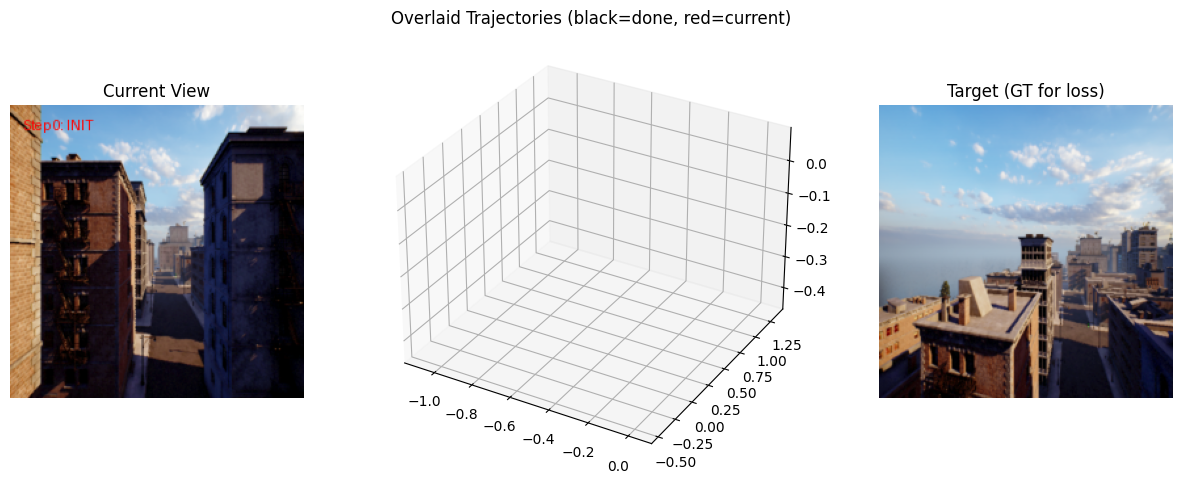

In [4]:
# === Preview in notebook (interactive) ===
fig, anim = build_master_animation(ROOT, fps=FPS, pause_sec=PAUSE_SEC, overlay_text=True)
# HTML(anim.to_jshtml())

In [5]:
anim.save(MASTER_OUT, writer='ffmpeg', fps=FPS)
plt.close(fig)
print(f"[OK] Master saved: {MASTER_OUT}")

[OK] Master saved: /data1/tpz/nwm-main/results/nwm_cdit_airvln_16/airvln_16/CEM_N6_K5_RS1_rep3_OPT3/editor/run_006/master.mp4
